In [1]:
# 6.6 Q1 - Graduate Admission Prediction

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (confusion_matrix, accuracy_score,
    classification_report, roc_curve, auc)

In [3]:
df = pd.read_csv('datasets/graduate_admission.csv')
print("Shape:", df.shape)
print(df.head())
print()
print("Class distribution:")
print(df['admit'].value_counts())

Shape: (400, 4)
   admit  gre   gpa  rank
0      0  380  3.61     3
1      1  660  3.67     3
2      1  800  4.00     1
3      1  640  3.19     4
4      0  520  2.93     4

Class distribution:
admit
0    273
1    127
Name: count, dtype: int64


In [4]:
print("Null values:")
print(df.isnull().sum())

Null values:
admit    0
gre      0
gpa      0
rank     0
dtype: int64


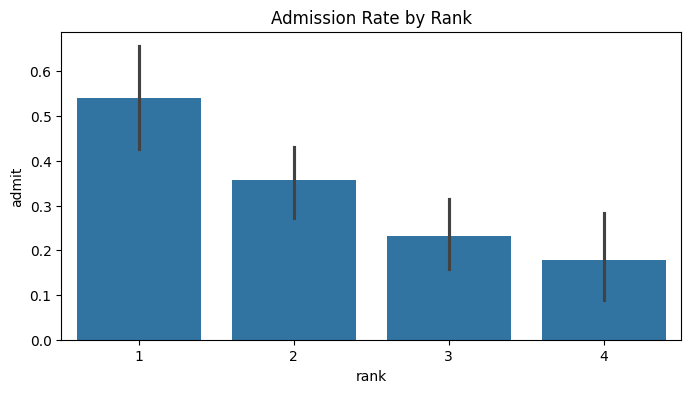

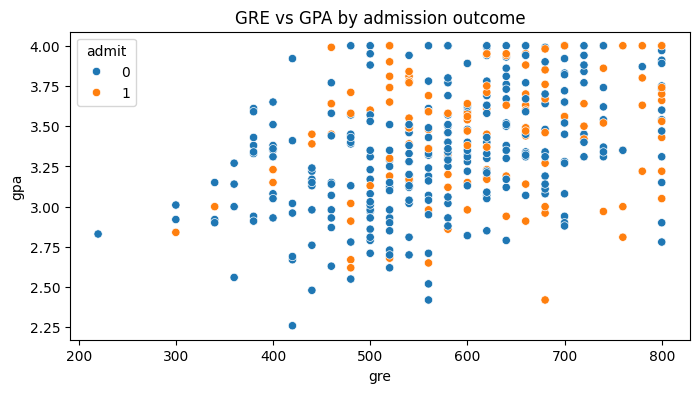

In [5]:
plt.figure(figsize=(8, 4))
sns.barplot(x='rank', y='admit', data=df)
plt.title('Admission Rate by Rank')
plt.show()

plt.figure(figsize=(8, 4))
sns.scatterplot(x='gre', y='gpa', hue='admit', data=df)
plt.title('GRE vs GPA by admission outcome')
plt.show()

In [6]:
# One-hot encode rank

In [7]:
df_model = pd.get_dummies(df, columns=['rank'], drop_first=True)
print("Columns:", list(df_model.columns))

y = df_model['admit']
X = df_model.drop(columns=['admit'])
print("X shape:", X.shape, "y shape:", y.shape)

Columns: ['admit', 'gre', 'gpa', 'rank_2', 'rank_3', 'rank_4']
X shape: (400, 5) y shape: (400,)


In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)
print("Train:", X_train.shape, "Test:", X_test.shape)

Train: (280, 5) Test: (120, 5)


In [9]:
sc = StandardScaler()
X_train_s = sc.fit_transform(X_train)
X_test_s  = sc.transform(X_test)

model = LogisticRegression(solver='lbfgs', max_iter=1000)
model.fit(X_train_s, y_train)
y_pred = model.predict(X_test_s)
y_proba = model.predict_proba(X_test_s)[:, 1]

print("Coefficients:")
for n, c in zip(X.columns, model.coef_[0]):
    print("  " + n.ljust(15), round(c, 4))
print("Intercept:", round(float(model.intercept_[0]), 4))

Coefficients:
  gre             0.303
  gpa             0.2858
  rank_2          -0.1846
  rank_3          -0.5304
  rank_4          -0.4889
Intercept: -0.8581


In [10]:
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)
print("Accuracy:", accuracy_score(y_test, y_pred))
print()
print(classification_report(y_test, y_pred))

Confusion Matrix:
[[77  5]
 [31  7]]
Accuracy: 0.7

              precision    recall  f1-score   support

           0       0.71      0.94      0.81        82
           1       0.58      0.18      0.28        38

    accuracy                           0.70       120
   macro avg       0.65      0.56      0.55       120
weighted avg       0.67      0.70      0.64       120



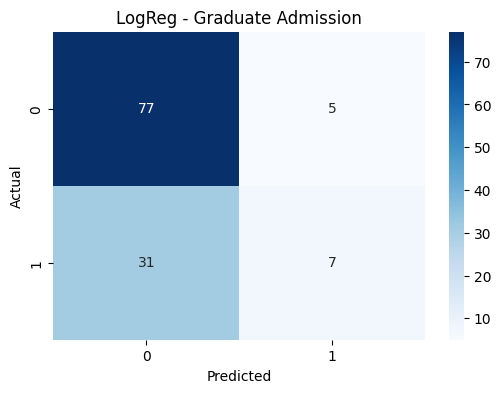

In [11]:
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('LogReg - Graduate Admission')
plt.show()

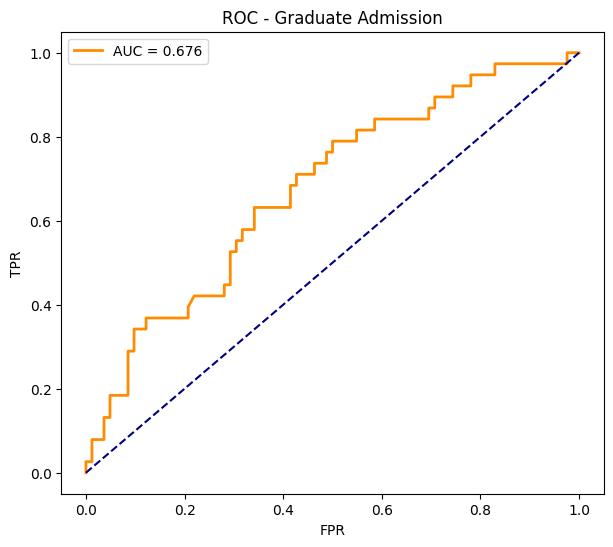

In [12]:
fpr, tpr, _ = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)
plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2,
         label='AUC = %.3f' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', linestyle='--')
plt.xlabel('FPR')
plt.ylabel('TPR')
plt.title('ROC - Graduate Admission')
plt.legend()
plt.show()